In [1]:
import NeuralImplicit as NI
import network_defs as net_defs
import torch
import importlib
import matplotlib.pyplot as plt
importlib.reload(net_defs)
importlib.reload(NI)
#set torch default dtype to float64
torch.set_default_dtype(torch.float64)


In [4]:
architecture = [2, 256,256,256,256,5]
model = net_defs.Siren_jo(architecture=architecture,outermost_linear=True, first_omega_0=15, hidden_omega_0=30)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.8)


Number of parameters: 199429


In [14]:
NUM_EPOCHS = 5000
BATCH_SIZE = 1024
FUN_NUM = 3
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0,
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      use_scheduler=True, 
                      device=torch.device('cpu'))


Epoch [0], Loss: 7.910758097902165e-05, Acc: 7.910758097902165e-05
Epoch [499], Loss: 6.289992398508514e-05, Acc: 6.289992398508514e-05
Epoch [999], Loss: 5.9818890825438374e-05, Acc: 5.9818890825438374e-05
Epoch [1499], Loss: 5.028229549647755e-05, Acc: 5.028229549647755e-05
Epoch [1999], Loss: 4.5484075569925704e-05, Acc: 4.5484075569925704e-05
Epoch [2499], Loss: 5.102555452812026e-05, Acc: 5.102555452812026e-05
Epoch [2999], Loss: 4.591210977666374e-05, Acc: 4.591210977666374e-05
Epoch [3499], Loss: 4.782793252876556e-05, Acc: 4.782793252876556e-05
Epoch [3999], Loss: 4.113535563488489e-05, Acc: 4.113535563488489e-05
Epoch [4499], Loss: 5.0720146694779475e-05, Acc: 5.0720146694779475e-05
Epoch [4999], Loss: 4.0045062927886996e-05, Acc: 4.0045062927886996e-05


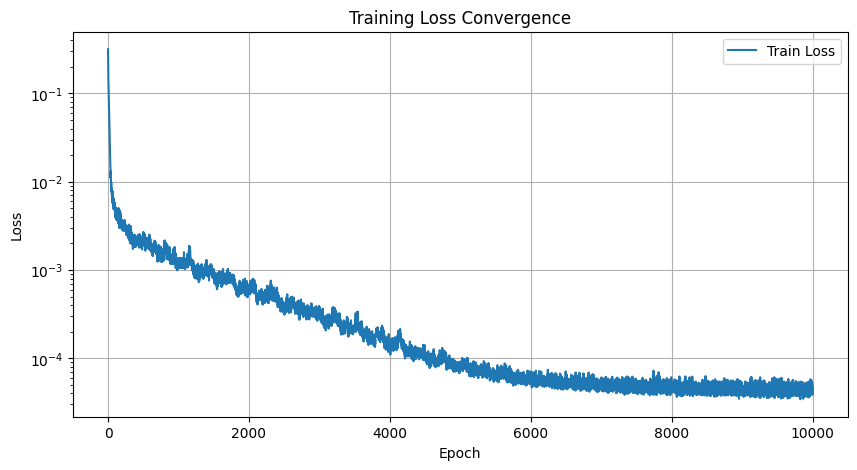

In [15]:
#plot convergence
plt.figure(figsize=(10,5))
plt.plot(model.loss_history, label='Train Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Convergence')
plt.legend()
plt.grid()
plt.show()

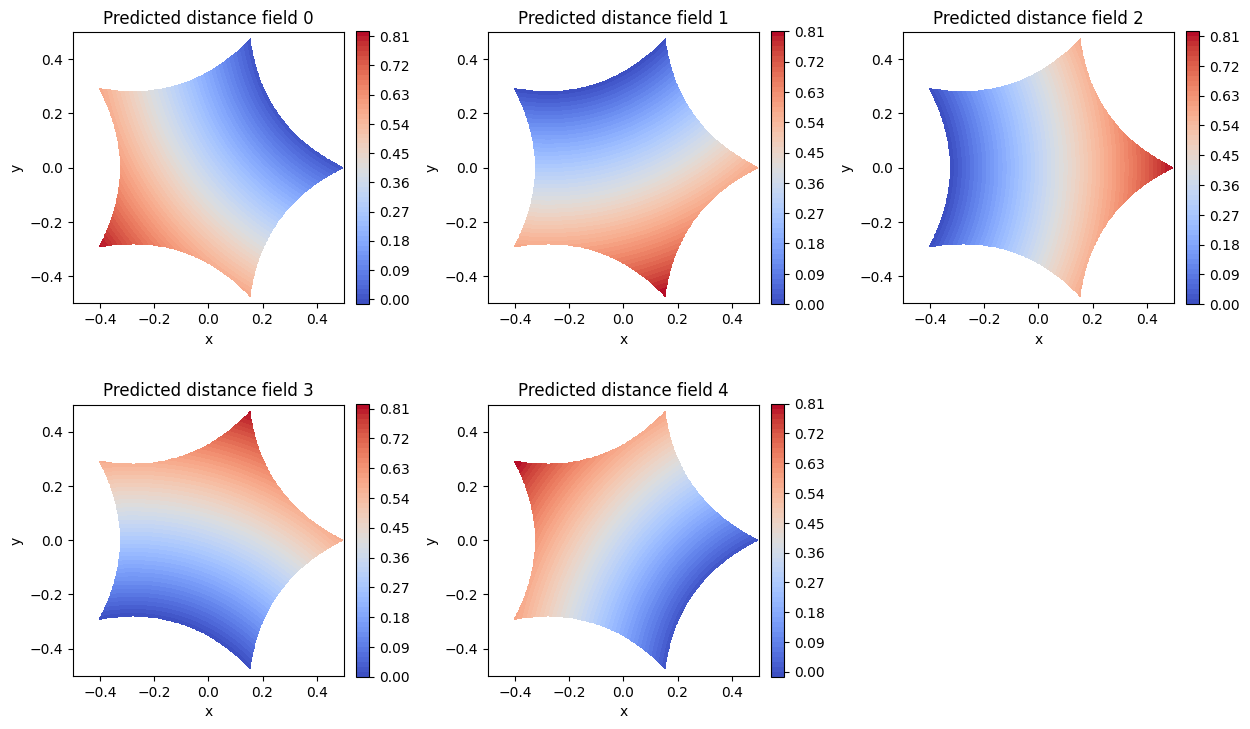

In [16]:
_=NI.plot_nn_distance_fields(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=FUN_NUM, device=torch.device('cpu'))

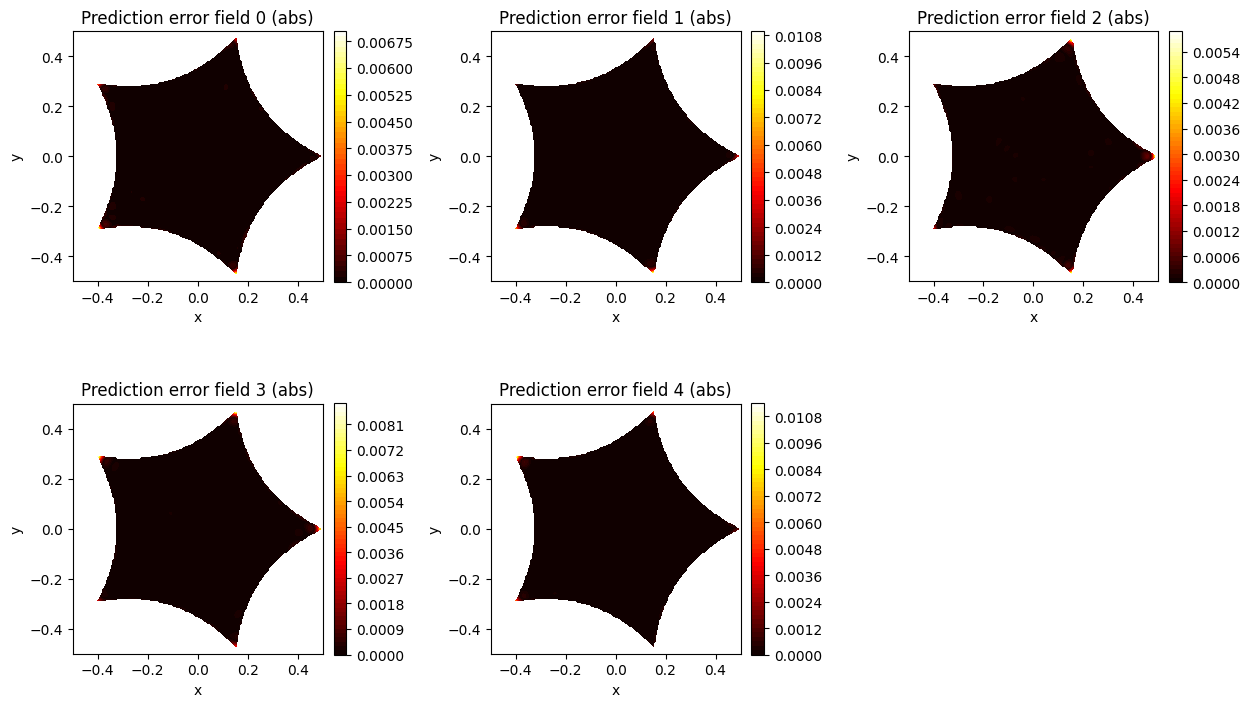

In [17]:
_=NI.plot_nn_prediction_error(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=FUN_NUM, device=torch.device('cpu'))

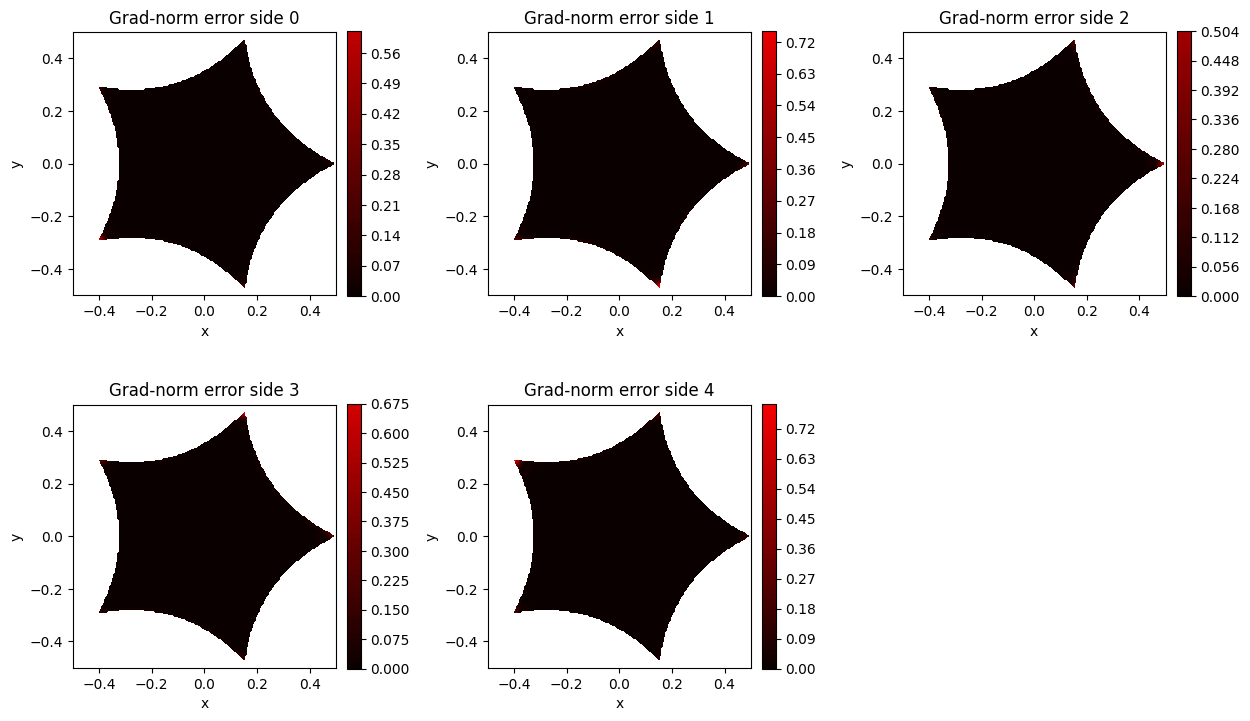

In [19]:
_=NI.plot_local_per_side_gradient_error(model, extent=[-0.5,0.5,-0.5,0.5],fun_num=FUN_NUM, device=torch.device('cpu'))

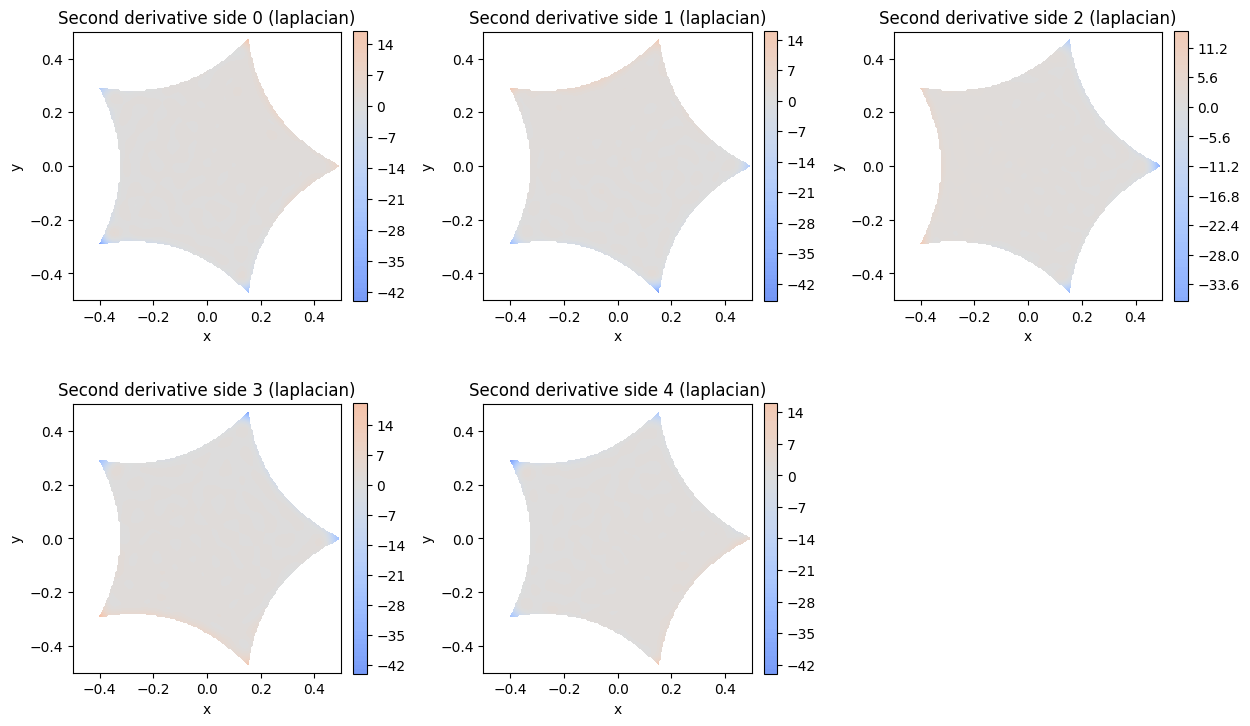

In [20]:
_=NI.plot_local_per_side_second_derivative(model, extent=[-0.5,0.5,-0.5,0.5], device=torch.device('cpu'),fun_num=FUN_NUM)

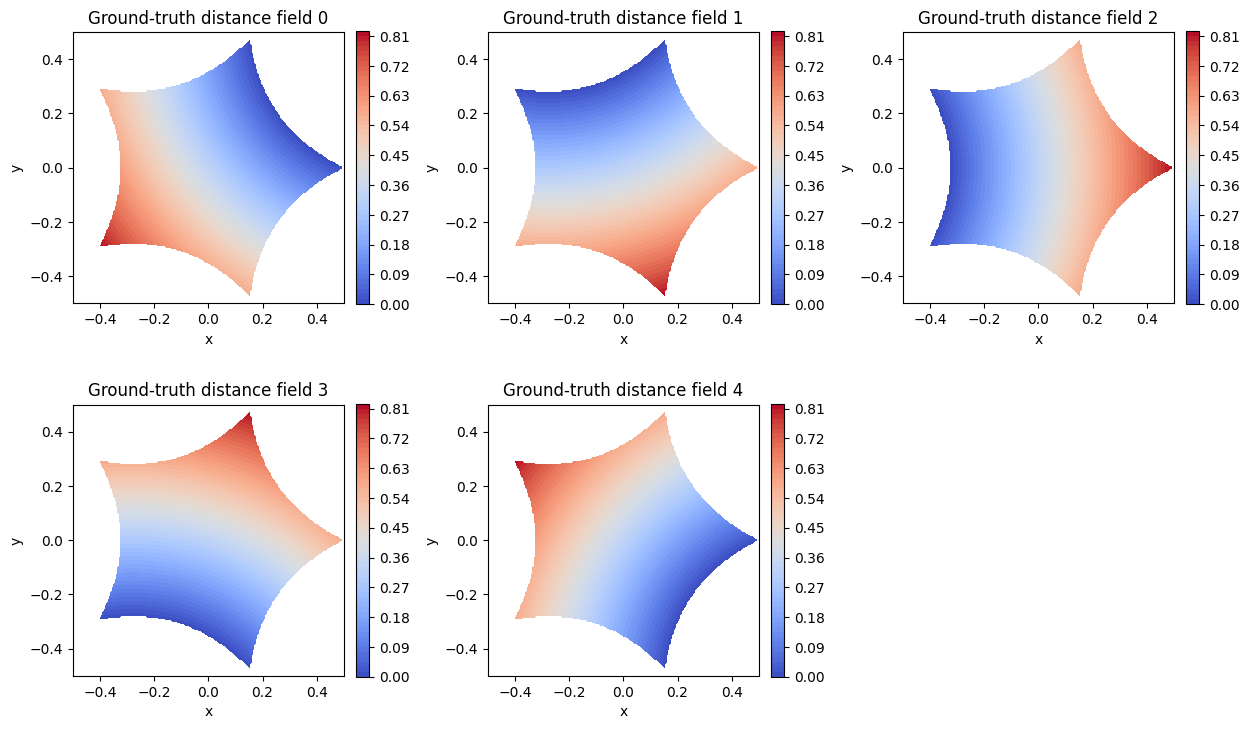

In [8]:
_= NI.plot_ground_truth_distance_fields(fun_num=3, extent=[-0.5,0.5,-0.5,0.5])